# 🌿 AI Crop Disease Detection using CNN & MobileNetV3

## End-to-End Deep Learning Project

**Objective:** Detect tomato leaf diseases from images using:
- Custom CNN
- MobileNetV3 Transfer Learning

The notebook covers the complete workflow:
**Setup → Dataset → EDA → Preprocessing → Augmentation → CNN → MobileNetV3 → Evaluation → Model Comparison → Single Image Prediction → Model Saving**

> Dataset: PlantVillage tomato leaf disease subset prepared in the project `dataset/` folder.


## 1. Import Libraries

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)


TensorFlow: 2.21.0
NumPy: 2.5.3


## 2. Project Configuration

In [2]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
CNN_EPOCHS = 10
MOBILENET_EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)


Project: d:\CNN project\Crop-disease-detection-CNN
Dataset: d:\CNN project\Crop-disease-detection-CNN\dataset


## 3. Check Dataset Structure

In [3]:
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print(f"\n{split_dir.name.upper()}")
    if split_dir.exists():
        for class_dir in sorted(split_dir.iterdir()):
            if class_dir.is_dir():
                print(f"{class_dir.name}: {len(list(class_dir.glob('*')))} images")
    else:
        print("Directory not found:", split_dir)



TRAIN
Tomato___Early_blight: 700 images
Tomato___healthy: 1113 images
Tomato___Late_blight: 1336 images
Tomato___Leaf_Mold: 666 images
Tomato___Septoria_leaf_spot: 1239 images

VALIDATION
Tomato___Early_blight: 150 images
Tomato___healthy: 238 images
Tomato___Late_blight: 286 images
Tomato___Leaf_Mold: 142 images
Tomato___Septoria_leaf_spot: 265 images

TEST
Tomato___Early_blight: 150 images
Tomato___healthy: 240 images
Tomato___Late_blight: 287 images
Tomato___Leaf_Mold: 144 images
Tomato___Septoria_leaf_spot: 267 images


## 4. Find Class Names

In [4]:
class_names = sorted([
    d.name for d in TRAIN_DIR.iterdir()
    if d.is_dir()
])

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Classes:")
for i, name in enumerate(class_names):
    print(i, "->", name)


Number of classes: 5
Classes:
0 -> Tomato___Early_blight
1 -> Tomato___Late_blight
2 -> Tomato___Leaf_Mold
3 -> Tomato___Septoria_leaf_spot
4 -> Tomato___healthy


## 5. Create Dataset Loaders

Images are resized to **224 × 224** and loaded as batches. Labels use one-hot encoding because the project has multiple disease classes.


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

print("Datasets loaded successfully.")


Found 5054 files belonging to 5 classes.
Found 1081 files belonging to 5 classes.
Found 1088 files belonging to 5 classes.
Datasets loaded successfully.


## 6. Improve Dataset Performance

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Prefetch enabled.")


Prefetch enabled.


## 7. Visualize Sample Images

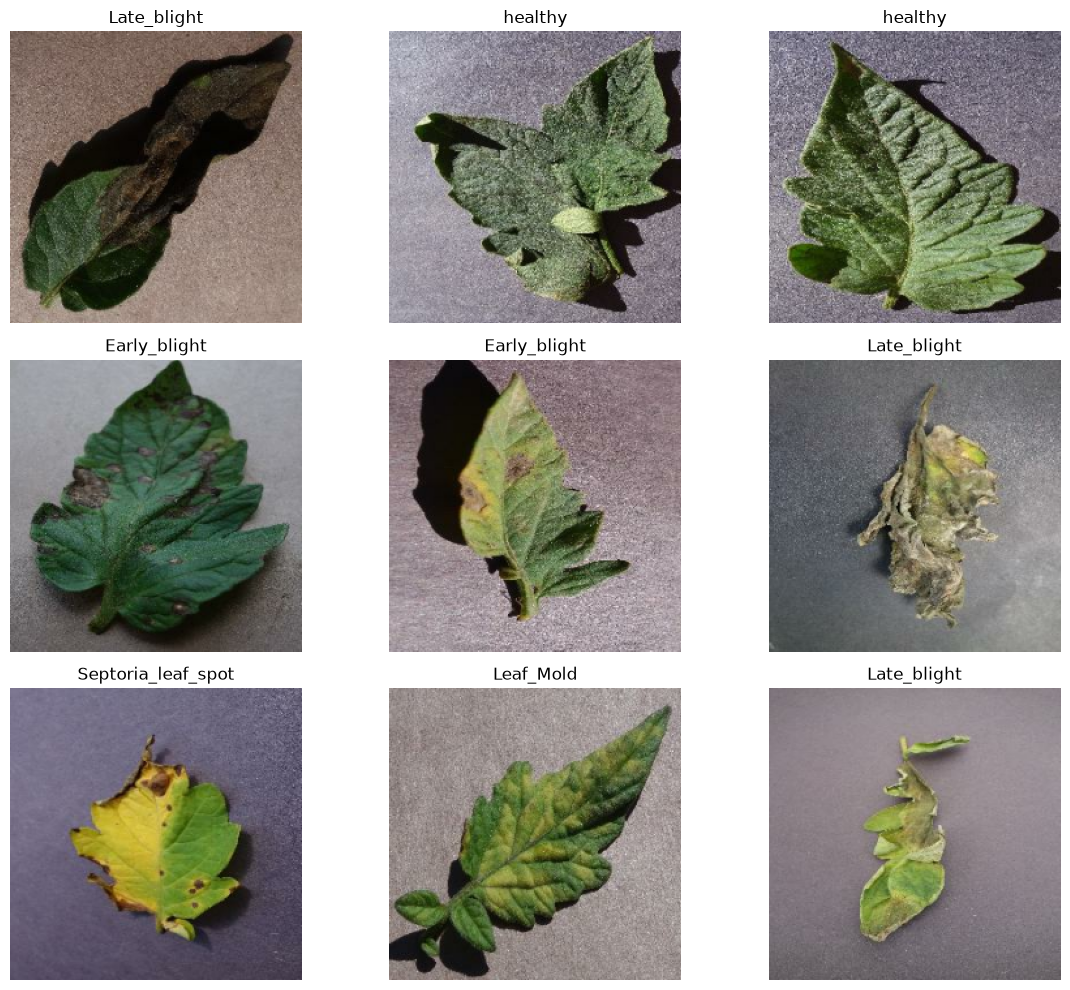

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 10))

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i].numpy())].replace("Tomato___", ""))
    plt.axis("off")

plt.tight_layout()
plt.show()


## 8. Dataset Distribution

,Class,Count
0,Early_blight,700
1,healthy,1113
2,Late_blight,1336
3,Leaf_Mold,666
4,Septoria_leaf_spot,1239


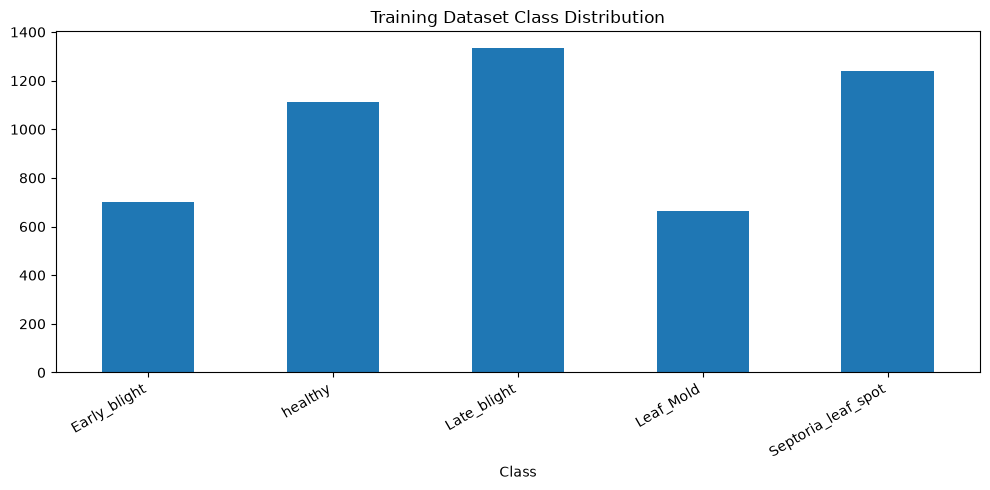

In [8]:
def count_images(folder):
    rows = []
    for class_dir in sorted(folder.iterdir()):
        if class_dir.is_dir():
            rows.append({
                "Class": class_dir.name.replace("Tomato___", ""),
                "Count": len(list(class_dir.glob("*")))
            })
    return pd.DataFrame(rows)

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

display(train_counts)

train_counts.plot(
    x="Class",
    y="Count",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Training Dataset Class Distribution"
)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 9. Data Augmentation

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation pipeline created.")


Data augmentation pipeline created.


# PART A — Custom CNN

## 11. Build the CNN Model

In [10]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),

    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.40),

    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
], name="Custom_CNN")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,077 (49.36 MB)

 Trainable params: 12,939,077 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print("Models folder:", MODELS_DIR)

Models folder: models


## 14. CNN Test Evaluation

In [12]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_ds, verbose=1)

print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")


68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.2619 - loss: 1.5978
CNN Test Loss: 1.5978
CNN Test Accuracy: 0.2619


# PART B — MobileNetV3 Transfer Learning

## 16. Build MobileNetV3 Model

MobileNetV3 is used as the transfer-learning model. The ImageNet feature extractor is initially frozen, while a new classification head learns the five tomato disease classes.


In [13]:
mobilenet_base = tf.keras.applications.MobileNetV3Small(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

mobilenet_base.trainable = False

mobilenet_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,

    tf.keras.layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    mobilenet_base,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
], name="MobileNetV3Small")

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()


Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         2,885 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,005 (3.59 MB)

 Trainable params: 2,885 (11.27 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 17. MobileNetV3 Training

In [14]:
mobilenet_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODELS_DIR / "mobilenetv3_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MOBILENET_EPOCHS,
    callbacks=mobilenet_callbacks
)


Epoch 1/10


d:\CNN project\Crop-disease-detection-CNN\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.2798 - loss: 1.5820
Epoch 1: val_accuracy improved from None to 0.38483, saving model to models\mobilenetv3_best.keras

Epoch 1: finished saving model to models\mobilenetv3_best.keras
316/316 ━━━━━━━━━━━━━━━━━━━━ 68s 195ms/step - accuracy: 0.2798 - loss: 1.5820 - val_accuracy: 0.3848 - val_loss: 1.5073 - learning_rate: 0.0010
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3407 - loss: 1.5256
Epoch 2: val_accuracy did not improve from 0.38483
316/316 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.3407 - loss: 1.5256 - val_accuracy: 0.3821 - val_loss: 1.4585 - learning_rate: 0.0010
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.3799 - loss: 1.4817
Epoch 3: val_accuracy did not improve from 0.38483
316/316 ━━━━━━━━━━━━━━━━━━━━ 50s 157ms/step - accuracy: 0.3799 - loss: 1.4817 - val_accuracy: 0.3682 - val_loss: 1.4397 - learning_rate: 0.0010
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/

## 19. MobileNetV3 Test Evaluation

In [15]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print(f"MobileNetV3 Test Loss: {mobilenet_test_loss:.4f}")
print(f"MobileNetV3 Test Accuracy: {mobilenet_test_accuracy:.4f}")


68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.3631 - loss: 1.4166
MobileNetV3 Test Loss: 1.4166
MobileNetV3 Test Accuracy: 0.3631


In [17]:
import numpy as np

def collect_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)

        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(y_true), np.array(y_pred)

print("collect_predictions function ready!")

collect_predictions function ready!


## 20. MobileNetV3 Classification Report

In [18]:
mobilenet_y_true, mobilenet_y_pred = collect_predictions(
    mobilenet_model,
    test_ds
)

print(classification_report(
    mobilenet_y_true,
    mobilenet_y_pred,
    target_names=[c.replace("Tomato___", "") for c in class_names],
    digits=4
))


                    precision    recall  f1-score   support

      Early_blight     0.0000    0.0000    0.0000       150
       Late_blight     0.3654    0.5958    0.4530       287
         Leaf_Mold     0.0000    0.0000    0.0000       144
Septoria_leaf_spot     0.3803    0.2022    0.2641       267
           healthy     0.3556    0.7083    0.4735       240

          accuracy                         0.3631      1088
         macro avg     0.2203    0.3013    0.2381      1088
      weighted avg     0.2682    0.3631    0.2887      1088



d:\CNN project\Crop-disease-detection-CNN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CNN project\Crop-disease-detection-CNN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CNN project\Crop-disease-detection-CNN\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [21]:
import tensorflow as tf

FINAL_MODEL_PATH = "models/crop_disease_best_model.keras"

best_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

print("Final CNN model loaded successfully!")

Final CNN model loaded successfully!


In [22]:
# Collect predictions for both models

cnn_y_true, cnn_y_pred = collect_predictions(
    best_model,
    test_ds
)

mobilenet_y_true, mobilenet_y_pred = collect_predictions(
    mobilenet_model,
    test_ds
)

print("CNN and MobileNetV3 predictions collected successfully!")

CNN and MobileNetV3 predictions collected successfully!


## 21. MobileNetV3 Confusion Matrix

In [23]:
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Score (Macro)": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

cnn_metrics = calculate_metrics(cnn_y_true, cnn_y_pred)
mobile_metrics = calculate_metrics(mobilenet_y_true, mobilenet_y_pred)

comparison_df = pd.DataFrame(
    [cnn_metrics, mobile_metrics],
    index=["Custom CNN", "MobileNetV3"]
)

display(comparison_df.round(4))


,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
Custom CNN,0.9320,0.9231,0.9274,0.9248
MobileNetV3,0.3631,0.2203,0.3013,0.2381


## 24. Select the Model Based on Test Macro-F1

The notebook records the measured test metrics rather than assuming which model performs better.


In [24]:
if mobile_metrics["F1 Score (Macro)"] >= cnn_metrics["F1 Score (Macro)"]:
    best_model = mobilenet_model
    best_model_name = "MobileNetV3"
    best_metrics = mobile_metrics
else:
    best_model = cnn_model
    best_model_name = "Custom CNN"
    best_metrics = cnn_metrics

print("Selected model based on measured test Macro-F1:", best_model_name)
print(best_metrics)


Selected model based on measured test Macro-F1: Custom CNN
{'Accuracy': 0.9319852941176471, 'Precision (Macro)': 0.9231364727783007, 'Recall (Macro)': 0.9274453644616703, 'F1 Score (Macro)': 0.9248442317394605}


# PART D — Save the Final Model

## 25. Save Best Model

In [25]:
FINAL_MODEL_PATH = MODELS_DIR / "crop_disease_best_model.keras"

best_model.save(FINAL_MODEL_PATH)

print("Final model saved to:")
print(FINAL_MODEL_PATH)


Final model saved to:
models\crop_disease_best_model.keras


## 26. Save Class Names

In [26]:
CLASS_NAMES_PATH = MODELS_DIR / "class_names.json"

with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

print("Class names saved to:", CLASS_NAMES_PATH)


Class names saved to: models\class_names.json


In [27]:
import tensorflow as tf

FINAL_MODEL_PATH = "models/crop_disease_best_model.keras"

best_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

print("Final model loaded successfully!")

Final model loaded successfully!


d:\CNN project\Crop-disease-detection-CNN\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


# PART E — Single Image Prediction

## 27. Prediction Function

In [28]:
def predict_image(image_path, model=best_model):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    batch = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(batch, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_class = class_names[predicted_index]
    confidence = float(probabilities[predicted_index])

    return predicted_class, confidence, probabilities


In [29]:
IMG_SIZE = (224, 224)

print("IMG_SIZE:", IMG_SIZE)

IMG_SIZE: (224, 224)


In [30]:
import numpy as np


In [31]:
import numpy as np
print("NumPy:", np.__version__)

NumPy: 2.5.3


In [32]:
class_names = [
    "Tomato___Early_blight",
    "Tomato___healthy",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot"
]

print("Class names loaded:", class_names)

Class names loaded: ['Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot']


## 28. Test Prediction

Change `IMAGE_PATH` to any tomato leaf image you want to test.


In [33]:
from pathlib import Path

# Automatically select one test image
test_images = list(Path("dataset/test").rglob("*.JPG"))

IMAGE_PATH = str(test_images[0])

# Make prediction
if IMAGE_PATH and Path(IMAGE_PATH).exists():
    predicted_class, confidence, probabilities = predict_image(IMAGE_PATH)

    print("Image:", IMAGE_PATH)
    print("Prediction:", predicted_class.replace("Tomato___", ""))
    print(f"Confidence: {confidence:.2%}")
else:
    print("Test image not found.")

Image: dataset\test\Tomato___Early_blight\image (104).JPG
Prediction: healthy
Confidence: 22.74%


In [34]:
from pathlib import Path

# Automatically select one test image
test_images = list(Path("dataset/test").rglob("*.jpg"))

IMAGE_PATH = str(test_images[0])

print("Test image:", IMAGE_PATH)

Test image: dataset\test\Tomato___Early_blight\image (104).JPG


## 29. Display Prediction Result

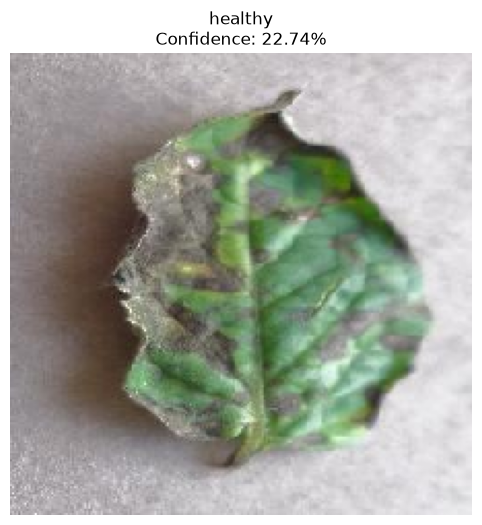

In [35]:
from pathlib import Path

# Select a test image
IMAGE_PATH = str(list(Path("dataset/test").rglob("*.JPG"))[0])

# Display prediction result
if Path(IMAGE_PATH).exists():
    image = tf.keras.utils.load_img(
        IMAGE_PATH,
        target_size=IMG_SIZE
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    plt.title(
        f"{predicted_class.replace('Tomato___', '')}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.axis("off")
    plt.show()

# PART F — Final Project Summary

## 30. Final Results

In [36]:
summary = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV3"],
    "Test Accuracy": [
        cnn_metrics["Accuracy"],
        mobile_metrics["Accuracy"]
    ],
    "Macro Precision": [
        cnn_metrics["Precision (Macro)"],
        mobile_metrics["Precision (Macro)"]
    ],
    "Macro Recall": [
        cnn_metrics["Recall (Macro)"],
        mobile_metrics["Recall (Macro)"]
    ],
    "Macro F1": [
        cnn_metrics["F1 Score (Macro)"],
        mobile_metrics["F1 Score (Macro)"]
    ]
})

display(summary.round(4))

print("\nFinal selected model:", best_model_name)
print("Final model path:", FINAL_MODEL_PATH)


,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,Custom CNN,0.9320,0.9231,0.9274,0.9248
1,MobileNetV3,0.3631,0.2203,0.3013,0.2381



Final selected model: Custom CNN
Final model path: models/crop_disease_best_model.keras


## 31. Project Conclusion

### Problem
Tomato leaf diseases need to be identified from leaf images.

### Approach
The project uses image classification with:
1. A custom CNN baseline.
2. MobileNetV3 transfer learning.

### Evaluation
Models are evaluated using:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Confusion Matrix
- Per-class classification report

### Deployment
The saved `.keras` model can be connected to the project's Streamlit application for image upload and prediction.

> **Important:** A model prediction is an image-classification result and should not be treated as a confirmed agricultural diagnosis or pesticide prescription.


## 32. Project Files Generated

After running the notebook, the main artifacts are expected under:

- `models/cnn_best.keras`
- `models/mobilenetv3_best.keras`
- `models/crop_disease_best_model.keras`
- `models/class_names.json`

The notebook itself is:

`Crop_Disease_Detection_CNN.ipynb`
